In [1]:
import pyspark.sql.functions as F
import pyspark.sql.types as T

import os 
import subprocess
import datetime
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import functions as F, Window
from pyspark.sql.types import *
from pyspark.sql.functions import corr, regexp_replace, lower, col
from pyspark.ml.feature import Tokenizer, StopWordsRemover

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

sns.set(style="whitegrid")

In [2]:
spark.conf.set("spark.sql.repl.eagerEval.enabled", True)
spark.conf.set("spark.sql.repl.eagerEval.maxCharsPerCell", 200)

In [3]:
reviews_path  = "gs://msca-bdp-students-bucket/kireetij_final/reviews_clean"
meta_path = "gs://msca-bdp-students-bucket/kireetij_final/meta_clean"

df_reviews = spark.read.parquet(reviews_path)
df_meta    = spark.read.parquet(meta_path)

print("Reviews:", df_reviews.count())
print("Meta:", df_meta.count())

df_reviews.printSchema()
df_meta.printSchema()

Reviews: 59966506
Meta: 1751297
root
 |-- asin: string (nullable = true)
 |-- helpful_vote: long (nullable = true)
 |-- parent_asin: string (nullable = true)
 |-- rating: double (nullable = true)
 |-- text: string (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- title: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- verified_purchase: boolean (nullable = true)
 |-- review_ts: timestamp (nullable = true)
 |-- review_date: date (nullable = true)

root
 |-- average_rating: double (nullable = true)
 |-- categories: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- main_category: string (nullable = true)
 |-- parent_asin: string (nullable = true)
 |-- rating_number: long (nullable = true)
 |-- title: string (nullable = true)
 |-- price_num: double (nullable = true)



In [ ]:
# SECTION 2.1
# What is the timeline of the dta? do you see any significant peaks and valleys?
# Do you see any data collection gaps?
# Do you seen any outliers?
# Do you see any spikes

In [15]:
df_reviews_timeline = df_reviews.filter(
    (F.year("review_date") >= 2012) & (F.year("review_date") <= 2030)
)

df_reviews_timeline = df_reviews_timeline.withColumn(
    "year_month",
    F.date_trunc("month", F.col("review_date"))
)

df_reviews_timeline.limit(5).show()

+----------+------------+-----------+------+--------------------+-------------+--------------------+--------------------+-----------------+-------------------+-----------+-------------------+
|      asin|helpful_vote|parent_asin|rating|                text|    timestamp|               title|             user_id|verified_purchase|          review_ts|review_date|         year_month|
+----------+------------+-----------+------+--------------------+-------------+--------------------+--------------------+-----------------+-------------------+-----------+-------------------+
|B0026RHE36|           0| B0026RHE36|   5.0|good job keep it ...|1325445077000|         Phone Cover|AFEK4RGHNN5R5HQ5H...|             true|2012-01-01 19:11:17| 2012-01-01|2012-01-01 00:00:00|
|B000F6TYAQ|           1| B000F6TYAQ|   4.0|I purchased this ...|1325448521000|Almost Perfect To...|AEQWN5EPEONQFGSLN...|             true|2012-01-01 20:08:41| 2012-01-01|2012-01-01 00:00:00|
|B0044M6IJM|           0| B0044M6IJM|   

In [16]:
monthly_counts = (
    df_reviews_timeline
    .groupBy("year_month")
    .count()
    .orderBy("year_month")
)

pdf = monthly_counts.toPandas()

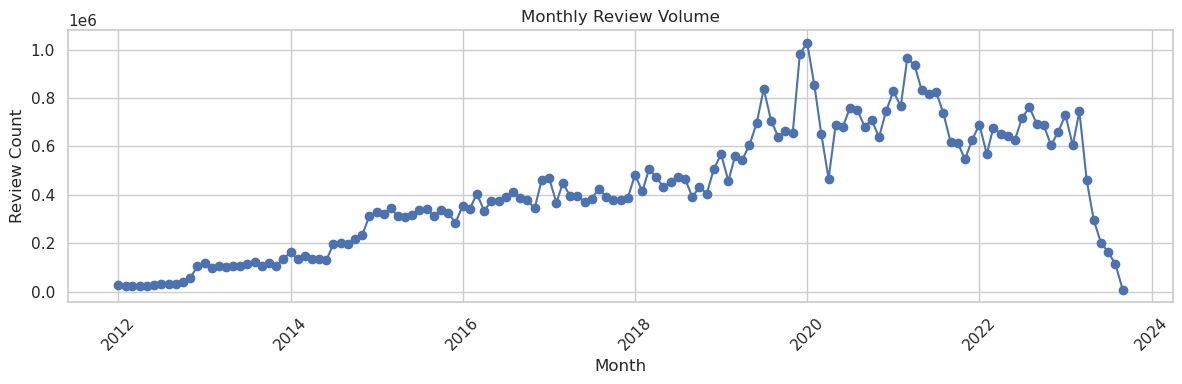

In [17]:
%matplotlib inline
plt.figure(figsize=(12,4))
plt.plot(pdf["year_month"], pdf["count"], marker='o')
plt.title("Monthly Review Volume")
plt.xlabel("Month")
plt.ylabel("Review Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
print("Top 10 peak months:")
pdf.sort_values("count", ascending=False).head(10)

Top 10 peak months:


,year_month,count
96,2020-01-01,1028917
95,2019-12-01,980901
110,2021-03-01,964476
111,2021-04-01,935009
97,2020-02-01,851955
90,2019-07-01,838178
112,2021-05-01,832169
108,2021-01-01,828616
114,2021-07-01,826234
113,2021-06-01,816818


In [19]:
print("Bottom 10 lowest-volume months:")
pdf.sort_values("count", ascending=True).head(10)

Bottom 10 lowest-volume months:


,year_month,count
140,2023-09-01,7888
1,2012-02-01,23376
3,2012-04-01,23666
2,2012-03-01,24342
4,2012-05-01,24545
5,2012-06-01,26366
0,2012-01-01,27993
7,2012-08-01,30732
6,2012-07-01,30894
8,2012-09-01,33021


In [ ]:
# What are the top 10 products with the most reviews?
# How does their review count trend over time?

In [9]:
top_products = (
    df_reviews_timeline
    .groupBy("parent_asin")
    .count()
    .orderBy(F.desc("count"))
    .limit(10)
)

top_products.show()

+-----------+-----+
|parent_asin|count|
+-----------+-----+
| B01415QHYW|41824|
| B01LSUQSB0|35636|
| B0BVGHXZJ1|33362|
| B07P9S6R9Y|28392|
| B001MA0QY2|25877|
| B01ITNRGFG|24437|
| B073R68TSH|24366|
| B07H2V5YLH|24248|
| B0C7CZXBBT|23755|
| B0BYBCFHTB|22787|
+-----------+-----+



In [10]:
top_asins = [row["parent_asin"] for row in top_products.collect()]

df_top = df_reviews_timeline.filter(F.col("parent_asin").isin(top_asins))

trend_df = (
    df_top.groupBy("parent_asin", "year_month")
          .count()
          .orderBy("parent_asin", "year_month")
)

pdf_trend = trend_df.toPandas()

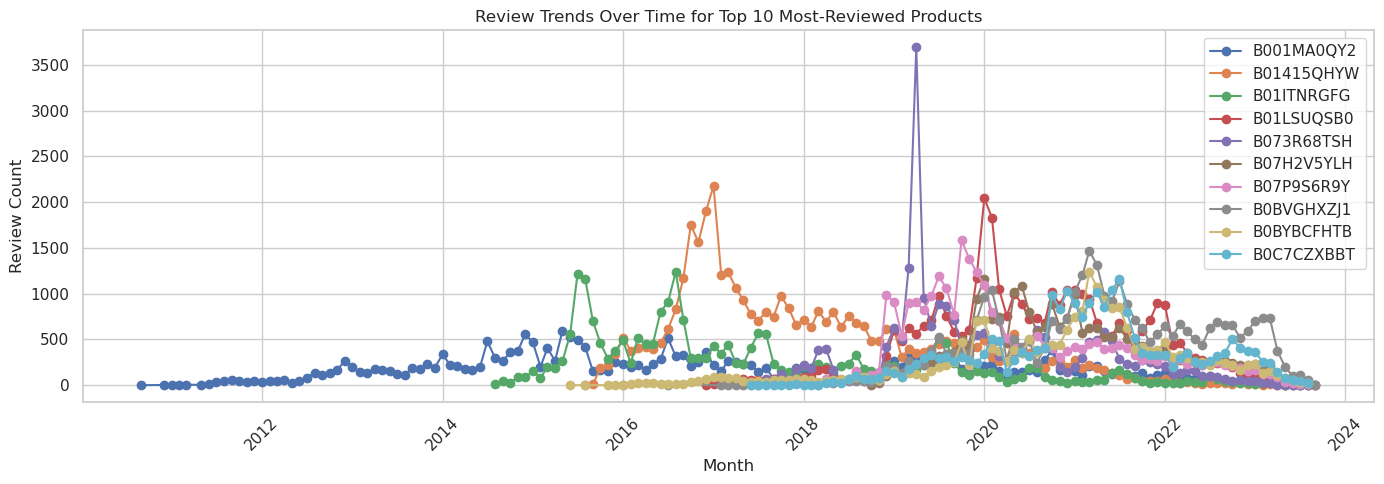

In [11]:
%matplotlib inline
plt.figure(figsize=(14,5))
for asin in pdf_trend["parent_asin"].unique():
    subset = pdf_trend[pdf_trend["parent_asin"] == asin]
    plt.plot(subset["year_month"], subset["count"], marker='o', label=asin)

plt.title("Review Trends Over Time for Top 10 Most-Reviewed Products")
plt.xlabel("Month")
plt.ylabel("Review Count")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# How does review volume vary across product categories (e.g., Books,
# Electronics, Beauty)?
# Do certain categories see spikes in review volume during specific
# months (e.g., holidays, sales)?

In [12]:
df_cat = df_reviews_timeline.join(
    df_meta.select("parent_asin", "main_category"),
    on="parent_asin",
    how="left"
)

category_counts = (
    df_cat.groupBy("main_category")
          .count()
          .orderBy(F.desc("count"))
)

category_counts.show(20)

+--------------------+--------+
|       main_category|   count|
+--------------------+--------+
|                NULL|21020666|
|          Automotive|12430003|
|          All Beauty|11785871|
|Cell Phones & Acc...| 8054059|
|Health & Personal...| 1269652|
|     All Electronics| 1105714|
|      Premium Beauty|  840774|
|Tools & Home Impr...|  772881|
|         Amazon Home|  754139|
|Industrial & Scie...|  567746|
|      AMAZON FASHION|  533231|
|   Sports & Outdoors|  222118|
|           Computers|  141621|
|      Camera & Photo|  139570|
|     Car Electronics|   72755|
|        Toys & Games|   41784|
|          Appliances|   36842|
|     Office Products|   34708|
|Arts, Crafts & Se...|   29276|
|        Pet Supplies|   26634|
+--------------------+--------+
only showing top 20 rows



In [21]:
top_categories = (
    category_counts.limit(4)
                   .toPandas()["main_category"]
                   .tolist()
)

df_top_cat = df_cat.filter(F.col("main_category").isin(top_categories))

df_top_cat = df_top_cat.filter((F.year("review_date") >= 2016) & (F.year("review_date") <= 2030))

cat_monthly = (
    df_top_cat.groupBy("main_category", "year_month")
              .count()
              .orderBy("main_category", "year_month")
)

pdf_cat = cat_monthly.toPandas()

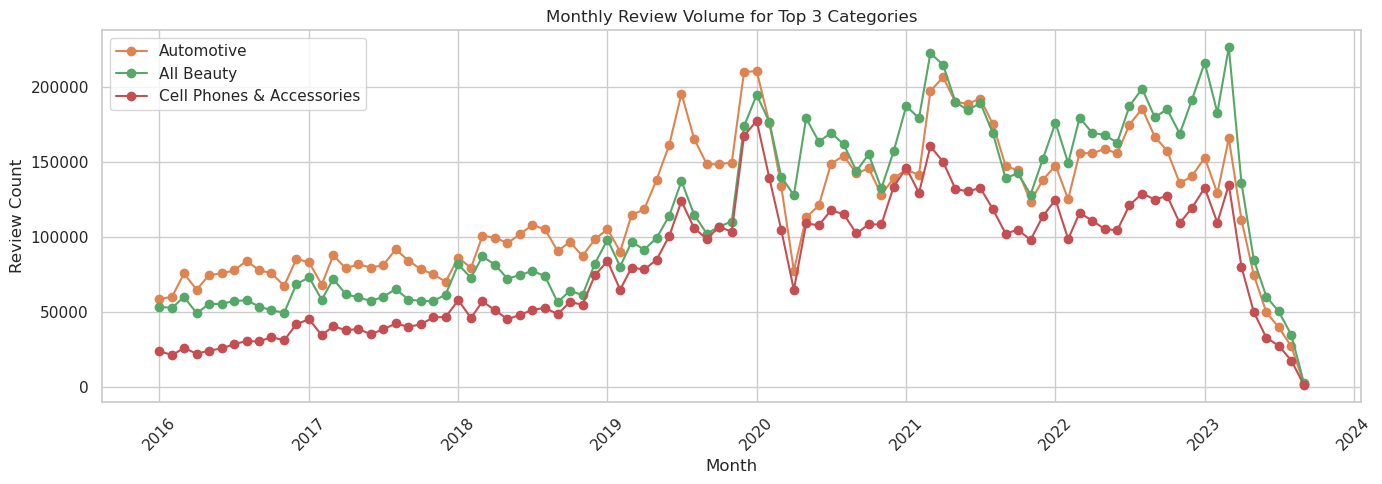

In [22]:
plt.figure(figsize=(14,5))
for cat in top_categories:
    subset = pdf_cat[pdf_cat["main_category"] == cat]
    plt.plot(subset["year_month"], subset["count"], marker='o', label=cat)

plt.title("Monthly Review Volume for Top 3 Categories")
plt.xlabel("Month")
plt.ylabel("Review Count")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Are products with extremely high average ratings (4.9–5.0) also the
# most-reviewed?
# Is there a relationship between product price and average rating or review
# volume?

In [16]:
product_stats = (
    df_reviews.groupBy("parent_asin")
              .agg(
                  F.count("*").alias("review_count"),
                  F.avg("rating").alias("avg_rating")
              )
)

product_stats = product_stats.join(
    df_meta.select("parent_asin", "price_num"),
    on="parent_asin",
    how="left"
)

product_pdf = product_stats.toPandas()
product_pdf.head()

,parent_asin,review_count,avg_rating,price_num
0,B0009F1ST8,5,4.400000,NaN
1,B004I3VS38,20,3.650000,NaN
2,B0055DNNP6,6,4.333333,NaN
3,B01I9TJPF4,153,4.490196,5.12
4,B008A04D1E,7,4.571429,104.99


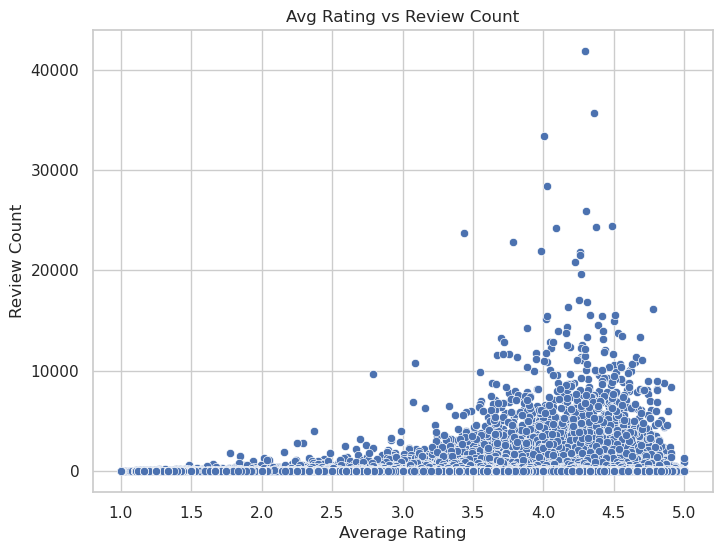

In [17]:
%matplotlib inline
plt.figure(figsize=(8,6))
sns.scatterplot(data=product_pdf, x="avg_rating", y="review_count")
plt.title("Avg Rating vs Review Count")
plt.xlabel("Average Rating")
plt.ylabel("Review Count")
plt.show()

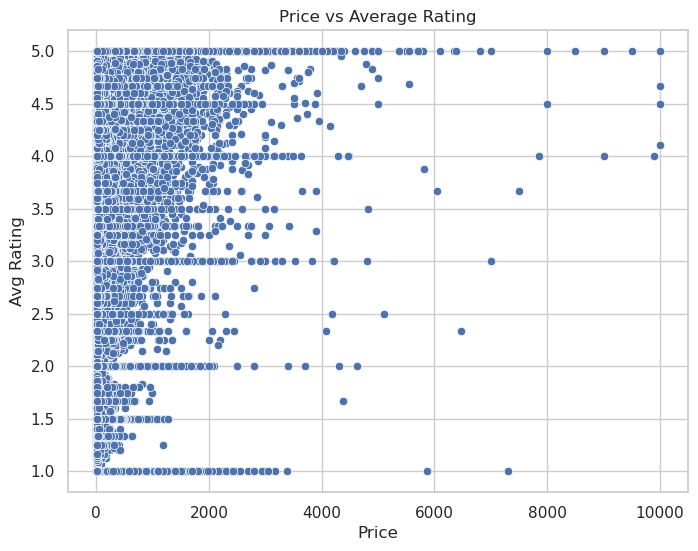

In [18]:
%matplotlib inline
plt.figure(figsize=(8,6))
sns.scatterplot(data=product_pdf, x="price_num", y="avg_rating")
plt.title("Price vs Average Rating")
plt.xlabel("Price")
plt.ylabel("Avg Rating")
plt.show()

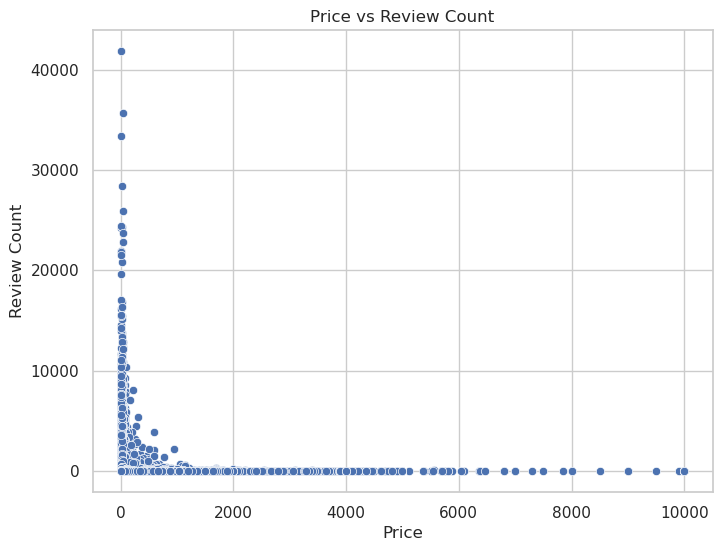

In [19]:
%matplotlib inline 
plt.figure(figsize=(8,6))
sns.scatterplot(data=product_pdf, x="price_num", y="review_count")
plt.title("Price vs Review Count")
plt.xlabel("Price")
plt.ylabel("Review Count")
plt.show()

In [ ]:
# What are the most common words or phrases in 5-star vs. 1-star reviews?
# Identify the most active reviewers
# By count
# Do top reviewers write across diverse categories or just a few?

In [20]:
df_5 = df_reviews.filter(F.col("rating") == 5.0).sample(False, 0.02, seed=42)
df_1 = df_reviews.filter(F.col("rating") == 1.0).sample(False, 0.05, seed=42)

def tokenize(df):
    return (
        df.withColumn("word", F.explode(F.split(F.lower(F.col("text")), "\\s+")))
          .filter(F.length("word") > 3)
          .filter(~F.col("word").isin("this","that","with","from","about","have","just"))
    )

words_5 = tokenize(df_5).groupBy("word").count().orderBy(F.desc("count")).limit(20)
words_1 = tokenize(df_1).groupBy("word").count().orderBy(F.desc("count")).limit(20)

words_5.show()
words_1.show()

+-------+------+
|   word| count|
+-------+------+
|  great|163916|
|   very|137084|
|   love|124379|
|   good| 93942|
|   easy| 90172|
|   like| 89122|
|   they| 80548|
|  phone| 73593|
|  works| 73407|
|product| 73006|
|  these| 65028|
|   will| 59171|
|   case| 58795|
|   hair| 54713|
| really| 53117|
|  would| 51399|
|   when| 50823|
|   your| 50245|
|   well| 49472|
|   it's| 48477|
+-------+------+



+-------+-----+
|   word|count|
+-------+-----+
|   they|57425|
|   very|54670|
|product|51410|
|   like|48639|
|  phone|45432|
|  would|45175|
|  after|43397|
|   when|38836|
|   will|36963|
|   your|35242|
|   even|35170|
|   case|33256|
|  these|31486|
|   does|31483|
|   only|30972|
| screen|30637|
|   work|29274|
|because|25409|
|   what|25291|
|   them|24947|
+-------+-----+



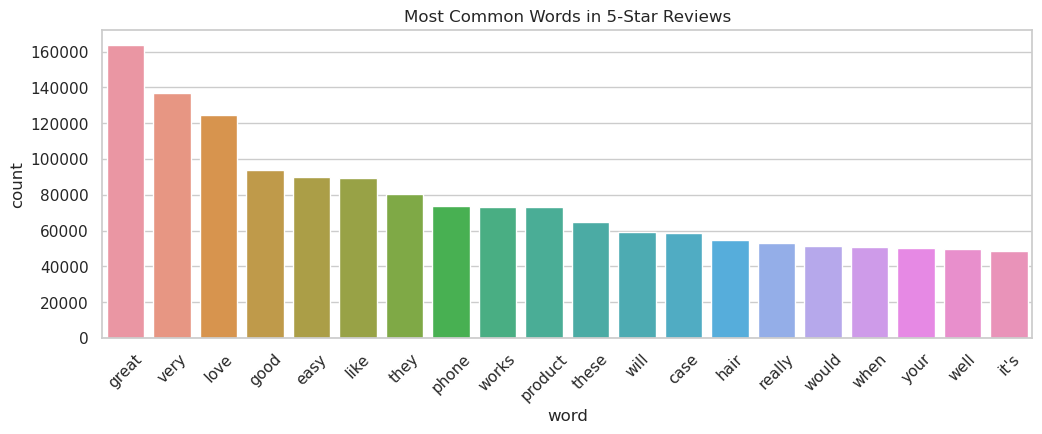

In [25]:
pdf5 = words_5.toPandas()
pdf1 = words_1.toPandas()

%matplotlib inline 
plt.figure(figsize=(12,4))
sns.barplot(data=pdf5, x="word", y="count")
plt.xticks(rotation=45)
plt.title("Most Common Words in 5-Star Reviews")
plt.show()

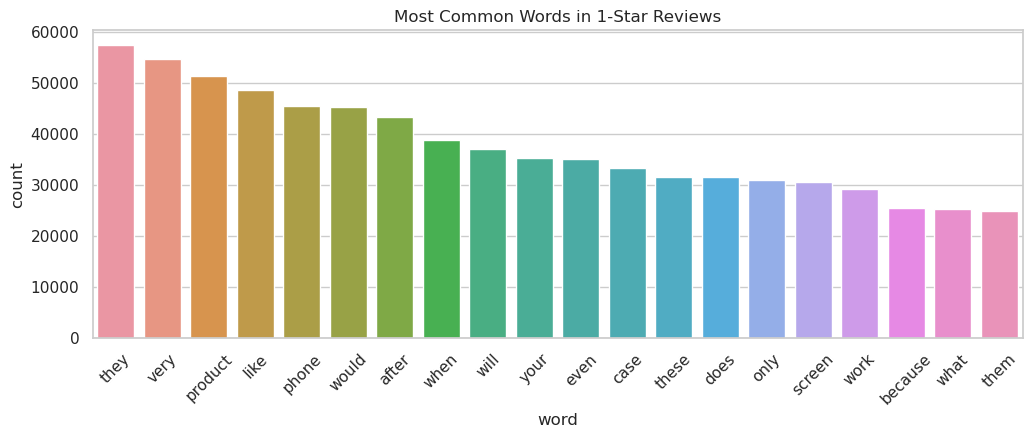

In [26]:
%matplotlib inline 
plt.figure(figsize=(12,4))
sns.barplot(data=pdf1, x="word", y="count")
plt.xticks(rotation=45)
plt.title("Most Common Words in 1-Star Reviews")
plt.show()

In [23]:
top_reviewers = (
    df_reviews.groupBy("user_id")
              .count()
              .orderBy(F.desc("count"))
              .limit(20)
)

top_reviewers.show()

+--------------------+-----+
|             user_id|count|
+--------------------+-----+
|AFTZWAK3ZHAPCNSOT...|  883|
|AGUTZC4GHLTGYHA3K...|  827|
|AHH67GCRGS45Y67OZ...|  522|
|AEYKTZXAWOPJG5MGG...|  433|
|AEYKTZXAWOPJG5MGG...|  412|
|AGCP66OOWFSGHQGQO...|  404|
|AGSXMEKFKM2HDFZ4U...|  390|
|AGFN3252BBTYUJUUD...|  381|
|AGFN3252BBTYUJUUD...|  379|
|AHP6Z5H7TMGBO55O2...|  377|
|AGRHKDNSRJ3CT5ST7...|  353|
|AFZUK3MTBIBEDQOPA...|  352|
|AGPC7CWRQPMNQFXWL...|  351|
|AFP2Z2JLDXU6PYRZF...|  342|
|AFEYKY4PX6MMT64Q4...|  338|
|AFNMU7RPT24NMJKGD...|  336|
|AH2OSSSLGXNEFZBCU...|  316|
|AG2RNXP7TLAF6RR7B...|  314|
|AE2K6NGRXS6NMFLFW...|  314|
|AEFTRCMDX2VGCKEW4...|  299|
+--------------------+-----+



In [24]:
df_user_cat = df_reviews.join(
    df_meta.select("parent_asin", "main_category"),
    on="parent_asin",
    how="left"
)

user_diversity = (
    df_user_cat.groupBy("user_id")
               .agg(
                    F.count("*").alias("review_count"),
                    F.countDistinct("main_category").alias("num_categories")
               )
)

top_reviewers_list = [r["user_id"] for r in top_reviewers.collect()]

user_diversity.filter(F.col("user_id").isin(top_reviewers_list)).show(20, truncate=False)

+--------------------------------+------------+--------------+
|user_id                         |review_count|num_categories|
+--------------------------------+------------+--------------+
|AGUTZC4GHLTGYHA3KBEDRF6MHB6A    |827         |14            |
|AGFN3252BBTYUJUUDQMAGYZNUT5A_1  |381         |13            |
|AFTZWAK3ZHAPCNSOT5GCKQDECBTQ    |883         |17            |
|AGPC7CWRQPMNQFXWLYJYQYF7DCQA    |351         |10            |
|AGSXMEKFKM2HDFZ4UNE676O6D5LQ    |390         |8             |
|AGCP66OOWFSGHQGQOF5SLTY6HRNQ    |404         |7             |
|AEYKTZXAWOPJG5MGGMKBLRJR6Q3A_1  |433         |14            |
|AFEYKY4PX6MMT64Q4L57K5VWZ6LA    |338         |8             |
|AEYKTZXAWOPJG5MGGMKBLRJR6Q3A_2  |412         |10            |
|AHP6Z5H7TMGBO55O2PIB6HVR5VRQ    |377         |9             |
|AE2K6NGRXS6NMFLFWUMEYT7N4NPA    |314         |11            |
|AH2OSSSLGXNEFZBCUYANAUUFUNBA    |316         |11            |
|AG2RNXP7TLAF6RR7BMHMIYPGNX3Q    |314         |9       